In [66]:
import numpy as np
import pandas as pd
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/base_dummies.dta")

# Filtrar personas que reportaron su condición de actividad
df = df[df['estado'].isin([1, 2, 3])]

# Guardar la base filtrada
df.to_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/respondieron.dta", write_index=False)

In [68]:
import numpy as np
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/respondieron.dta")

# Paso 1: Reemplazar valores vacíos por NaN
df['ch14'] = df['ch14'].replace({'': np.nan})

# Paso 2: Convertir todos los valores a strings para manejarlos de forma uniforme
df['ch14'] = df['ch14'].astype(str).str.strip()

# Paso 3: Función para limpiar cada valor
def convertir_a_entero(valor):
    if valor in ['98', '99', '98.0', '99.0']:
        return int(float(valor))  # mantener 98 y 99 como enteros
    try:
        # Convertimos valores como '01', '2.0', etc., a enteros
        return int(float(valor))
    except:
        return 0  # Si no se puede convertir, ponemos NaN

# Paso 4: Aplicar la función a toda la columna
df['ch14'] = df['ch14'].apply(convertir_a_entero)

In [70]:
df['ch12'] = pd.to_numeric(df['ch12'], errors='coerce')
df['ch13'] = pd.to_numeric(df['ch13'], errors='coerce')

In [72]:
import numpy as np
import pandas as pd

def calcular_anos_educacion(row):
    nivel = row['ch12']
    finalizo = row['ch13']
    ultimo_aprobado = row['ch14']

    if nivel == 9 or ultimo_aprobado in [98, 99]:
        return np.nan
    
    # Si finalizó el nivel
    if finalizo == 1:
        return {
            1: 0,
            2: 7,
            3: 9,
            4: 12,   # asumimos primaria + secundaria
            5: 12,
            6: 15,   # terciario
            7: 17,   # universitario
            8: 20,   # posgrado
        }.get(nivel, np.nan)

    # Si no lo finalizó
    if finalizo == 2:
        # Años previos al nivel actual
        previos = {
            1: 0,
            2: 0,
            3: 0,
            4: 9,
            5: 9,
            6: 12,
            7: 15,
            8: 17
        }.get(nivel, 0)

        # Validar que el año aprobado esté en rango
        if 1 <= ultimo_aprobado <= 9:
            return previos + ultimo_aprobado
        else:
            return np.nan

    return np.nan

# Asumiendo que tus datos están en un DataFrame llamado df:
df['anos_educacion'] = df.apply(calcular_anos_educacion, axis=1)

df.to_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/creamos_variable.dta", write_index=False)

/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_7209/1916775321.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['anos_educacion'] = df.apply(calcular_anos_educacion, axis=1)


In [74]:
import pandas as pd
import numpy as np

# Cargar el archivo .dta (asumimos que se cargó como df)
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/creamos_variable.dta")

# Filtrar los datos para eliminar ceros y valores negativos
df = df[df['p47t'] > 0]  # Suponiendo que 'p47t' es la columna de ingreso

# Recorte de outliers por percentiles
def sin_outliers(df, columna):
    q_low = df[columna].quantile(0.01)
    q_high = df[columna].quantile(0.99)
    return df[(df[columna] >= q_low) & (df[columna] <= q_high)]

# Aplicar el recorte de outliers en el DataFrame completo
df = sin_outliers(df, 'p47t')

# Ajustar por inflación, solo para los datos de 2004 (ano4 == 2004)
ajuste_inflacion = 500  # Factor de ajuste por inflación, ajusta según sea necesario
df.loc[df['ano4'] == 2004, 'p47t'] = df.loc[df['ano4'] == 2004, 'p47t'] * ajuste_inflacion

# Verificar el DataFrame después de los cambios
print(df[['ano4', 'p47t']].head())
# Crear la variable Edad al cuadrado (EDAD_CUAD)
df['edad_cuad'] = df['ch06']**2

# Crear la variable Experiencia potencial (EXPERIENCIA_POT)
df['experiencia_pot'] = df['ch06'] - df['nivel_ed'] - 6

# Crear la variable Edad * Experiencia (EDAD_X_EXP)
df['edad_x_exp'] = df['ch06'] * df['experiencia_pot']

# Crear la variable Logaritmo del ingreso (LOG_ING)
df['log_ing'] = np.log(df['p47t'])

# Crear la variable Ingresos laborales (ingreso total - ingresos no laborales)
df['ingreso_sin_subsidio'] = df['p47t'] - (df['t_vi'])

# Mostrar las primeras filas del DataFrame para verificar
print(df[['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'log_ing', 'ingreso_sin_subsidio']].head())


df.to_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/responieron_tp3.dta", write_index=False)

     ano4      p47t
0  2004.0  140000.0
2  2004.0   25000.0
3  2004.0  200000.0
5  2004.0  350000.0
8  2004.0  175000.0
   edad_cuad  experiencia_pot  edad_x_exp    log_ing  ingreso_sin_subsidio
0     5476.0             66.0      4884.0  11.849398              139720.0
2     1156.0             26.0       884.0  10.126631               25000.0
3      196.0              5.0        70.0  12.206073              199600.0
5     1225.0             25.0       875.0  12.765688              350000.0
8      900.0             21.0       630.0  12.072541              175000.0


/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_7209/1810086435.py:26: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['edad_cuad'] = df['ch06']**2
/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_7209/1810086435.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['experiencia_pot'] = df['ch06'] - df['nivel_ed'] - 6
/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_7209/1810086435.py:32: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` ma

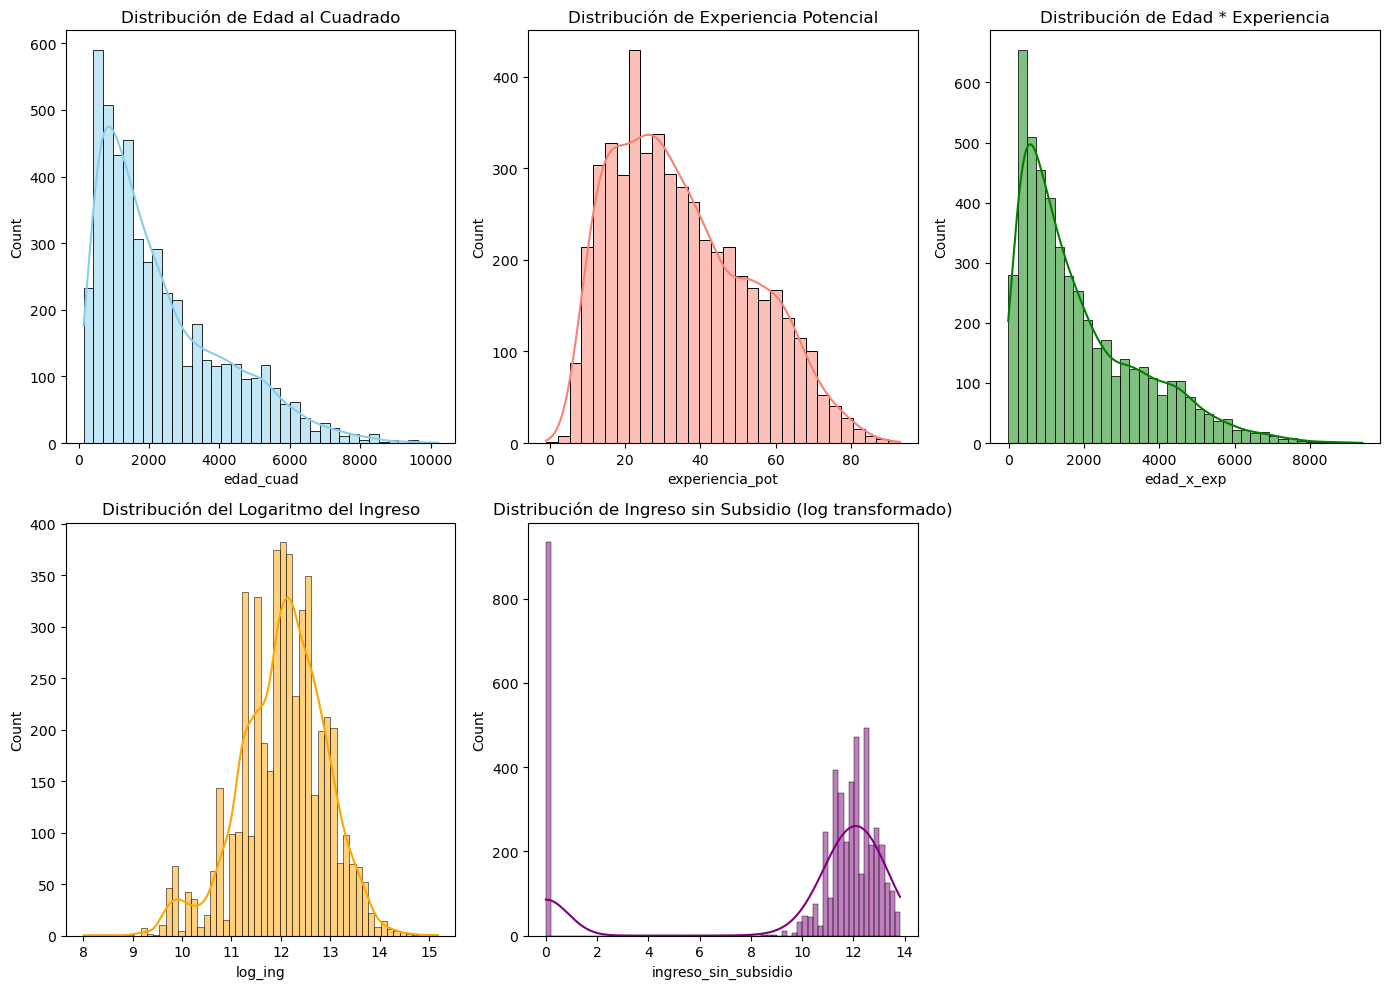

In [76]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Gráficos para variables continuas
plt.figure(figsize=(14, 10))

# Edad al cuadrado
plt.subplot(2, 3, 1)
sns.histplot(df['edad_cuad'], kde=True, color='skyblue')
plt.title('Distribución de Edad al Cuadrado')

# Experiencia potencial
plt.subplot(2, 3, 2)
sns.histplot(df['experiencia_pot'], kde=True, color='salmon')
plt.title('Distribución de Experiencia Potencial')

# Edad * Experiencia
plt.subplot(2, 3, 3)
sns.histplot(df['edad_x_exp'], kde=True, color='green')
plt.title('Distribución de Edad * Experiencia')

# Logaritmo del ingreso
plt.subplot(2, 3, 4)
sns.histplot(df['log_ing'], kde=True, color='orange')
plt.title('Distribución del Logaritmo del Ingreso')

# Ingreso sin subsidio con recorte y escala logarítmica
plt.subplot(2, 3, 5)
# Limitar los valores extremos (por ejemplo, a un percentil 99)
df_trimmed = df[df['ingreso_sin_subsidio'] < df['ingreso_sin_subsidio'].quantile(0.99)]
sns.histplot(np.log1p(df_trimmed['ingreso_sin_subsidio']), kde=True, color='purple')
plt.title('Distribución de Ingreso sin Subsidio (log transformado)')


plt.tight_layout()
plt.show()

## PARTE B

In [92]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Cargar la base de datos (esto asume que df es la base cargada previamente)
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/responieron_tp3.dta")

# Crear una dummy de 'desocupado' basada en una columna 'estado' (ajustar según el nombre real de la columna)
df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 'desocupado' else 0)

# Dividir por año (ano4 = 2004 o 2024)
df_2004 = df[df['ano4'] == 2004]
df_2024 = df[df['ano4'] == 2024]

# Función para dividir en entrenamiento y prueba
def split_data(df, random_state=444):
    # Seleccionar las variables específicas para X
    X = df[['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'log_ing', 'ingreso_sin_subsidio', 'anos_educacion']]  # Variables seleccionadas
    y = df['desocupado']  # Variable dependiente

    # Agregar columna de unos para la intersección (término constante)
    X = pd.concat([pd.Series(1, index=X.index, name='intercepto'), X], axis=1)

    # Dividir los datos en conjunto de entrenamiento (70%) y de prueba (30%)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=random_state)

    return X_train, X_test, y_train, y_test

# Dividir para 2004 y 2024
X_train_2004, X_test_2004, y_train_2004, y_test_2004 = split_data(df_2004)
X_train_2024, X_test_2024, y_train_2024, y_test_2024 = split_data(df_2024)


/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_7209/2505529577.py:8: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 'desocupado' else 0)


In [98]:
import pandas as pd

# Calcular las medias para las variables seleccionadas en el conjunto de entrenamiento y de prueba para 2004
mean_train_2004 = X_train_2004.mean()
mean_test_2004 = X_test_2004.mean()

# Calcular las medias para las variables seleccionadas en el conjunto de entrenamiento y de prueba para 2024
mean_train_2024 = X_train_2024.mean()
mean_test_2024 = X_test_2024.mean()

# Calcular la diferencia de medias entre el entrenamiento y testeo para 2004
difference_2004 = mean_train_2004 - mean_test_2004

# Calcular la diferencia de medias entre el entrenamiento y testeo para 2024
difference_2024 = mean_train_2024 - mean_test_2024

# Crear la tabla de diferencias de medias para 2004 y 2024
difference_table_2004 = pd.DataFrame({
    'Media Entrenamiento 2004': mean_train_2004.round(2),
    'Media Testeo 2004': mean_test_2004.round(2),
    'Diferencia de Medias 2004': difference_2004.round(2)
})

difference_table_2024 = pd.DataFrame({
    'Media Entrenamiento 2024': mean_train_2024.round(2),
    'Media Testeo 2024': mean_test_2024.round(2),
    'Diferencia de Medias 2024': difference_2024.round(2)
})

# Mostrar la tabla con estilo en Jupyter
print("Diferencia de medias para 2004:")
display(difference_table_2004.style.set_table_attributes('style="width: 100%;"'))

print("\nDiferencia de medias para 2024:")
display(difference_table_2024.style.set_table_attributes('style="width: 100%;"'))



Diferencia de medias para 2004:


,Media Entrenamiento 2004,Media Testeo 2004,Diferencia de Medias 2004
intercepto,1.000000,1.000000,0.000000
edad_cuad,2260.520000,2274.110000,-13.590000
experiencia_pot,34.690000,35.000000,-0.310000
edad_x_exp,1841.720000,1861.110000,-19.390000
log_ing,12.010000,12.020000,-0.010000
ingreso_sin_subsidio,244551.780000,249993.270000,-5441.480000
anos_educacion,11.000000,10.700000,0.300000



Diferencia de medias para 2024:


,Media Entrenamiento 2024,Media Testeo 2024,Diferencia de Medias 2024
intercepto,1.000000,1.000000,0.000000
edad_cuad,2376.600000,2366.900000,9.700000
experiencia_pot,35.430000,35.230000,0.200000
edad_x_exp,1930.220000,1917.330000,12.900000
log_ing,12.060000,12.090000,-0.030000
ingreso_sin_subsidio,165077.090000,178894.380000,-13817.290000
anos_educacion,12.100000,12.200000,-0.100000


In [100]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize


In [106]:

# Cargar la base de datos
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/responieron_tp3.dta")

# Crear una dummy de 'desocupado' basada en una columna 'estado' (ajustar según el nombre real de la columna)
df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 'desocupado' else 0)

# Dividir por año (ano4 = 2004 o 2024)
df_2004 = df[df['ano4'] == 2004]
df_2024 = df[df['ano4'] == 2024]

# Seleccionar las variables específicas para X
X = df[['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'log_ing', 'ingreso_sin_subsidio', 'anos_educacion']]  # Variables seleccionadas
y = df['desocupado']  # Variable dependiente

# Dividir los datos en conjunto de entrenamiento (70%) y de prueba (30%) para 2004
X_train_2004, X_test_2004, y_train_2004, y_test_2004 = train_test_split(X, y, test_size=0.3, random_state=444)

# Dividir los datos en conjunto de entrenamiento (70%) y de prueba (30%) para 2024
X_train_2024, X_test_2024, y_train_2024, y_test_2024 = train_test_split(X, y, test_size=0.3, random_state=444)

# Definir una función para entrenar los modelos y calcular las métricas
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)  # Ajustar el modelo
    y_pred = model.predict(X_test)  # Predicción
    
    # Calcular matriz de confusión
    conf_matrix = confusion_matrix(y_test, y_pred)
    
    # Asegurarse de que el modelo tiene el método predict_proba
    if hasattr(model, "predict_proba"):
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        # Calcular AUC y curva ROC
        fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
        auc_score = auc(fpr, tpr)
    else:
        fpr, tpr, auc_score = None, None, None
    
    # Calcular Accuracy
    accuracy = accuracy_score(y_test, y_pred)
    
    return conf_matrix, fpr, tpr, auc_score, accuracy

# Modelos a evaluar
models = {
    "Regresión Logística": LogisticRegression(),
    "Análisis Discriminante Lineal (LDA)": LinearDiscriminantAnalysis(),
    "Análisis Discriminante Cuadrático (QDA)": QuadraticDiscriminantAnalysis(),
    "KNN (K=5)": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

# Evaluación de cada modelo
for model_name, model in models.items():
    print(f"\nEvaluando {model_name}...")
    
    # Evaluación para el año 2004
    conf_matrix_2004, fpr_2004, tpr_2004, auc_2004, accuracy_2004 = train_and_evaluate_model(model, X_train_2004, X_test_2004, y_train_2004, y_test_2004)
    
    print(f"Matriz de Confusión (2004) para {model_name}:\n", conf_matrix_2004)
    print(f"AUC (2004) para {model_name}: {auc_2004:.2f}" if auc_2004 is not None else "AUC no disponible")
    print(f"Accuracy (2004) para {model_name}: {accuracy_2004:.2f}")
    
    # Evaluación para el año 2024
    conf_matrix_2024, fpr_2024, tpr_2024, auc_2024, accuracy_2024 = train_and_evaluate_model(model, X_train_2024, X_test_2024, y_train_2024, y_test_2024)
    
    print(f"Matriz de Confusión (2024) para {model_name}:\n", conf_matrix_2024)
    print(f"AUC (2024) para {model_name}: {auc_2024:.2f}" if auc_2024 is not None else "AUC no disponible")
    print(f"Accuracy (2024) para {model_name}: {accuracy_2024:.2f}")
    
    # Graficar la curva ROC si AUC es disponible
    if auc_2004 is not None and auc_2024 is not None:
        plt.figure(figsize=(10, 6))
        plt.plot(fpr_2004, tpr_2004, label=f'{model_name} (2004) AUC = {auc_2004:.2f}')
        plt.plot(fpr_2024, tpr_2024, label=f'{model_name} (2024) AUC = {auc_2024:.2f}')
        plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
        plt.title(f'Curva ROC para {model_name}')
        plt.xlabel('Tasa de Falsos Positivos (FPR)')
        plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
        plt.legend(loc='lower right')
        plt.show()



Evaluando Regresión Logística...


/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_7209/2099628344.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 'desocupado' else 0)


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

# Cargar la base de datos
df = pd.read_stata("/Users/zowi/Desktop/Big Data/GitHub/E337-Grupo3/TP3/responieron_tp3.dta")

# Crear una dummy de 'desocupado' basada en una columna 'estado' (ajustar según el nombre real de la columna)
df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 'desocupado' else 0)

# Dividir por año (ano4 = 2004 o 2024)
df_2004 = df[df['ano4'] == 2004]
df_2024 = df[df['ano4'] == 2024]

# Seleccionar las variables específicas para X
X = df[['edad_cuad', 'experiencia_pot', 'edad_x_exp', 'log_ing', 'ingreso_sin_subsidio', 'anos_educacion']]  # Variables seleccionadas
y = df['desocupado']  # Variable dependiente

# Dividir los datos en conjunto de entrenamiento (70%) y de prueba (30%) para 2004
X_train_2004, X_test_2004, y_train_2004, y_test_2004 = train_test_split(X, y, test_size=0.3, random_state=444)

# Crear el modelo de regresión logística
log_reg = LogisticRegression()
log_reg.fit(X_train_2004, y_train_2004)  # Ajustar el modelo con los datos de entrenamiento

# Realizar predicciones sobre el conjunto de prueba
y_pred_log = log_reg.predict(X_test_2004)

# Calcular la matriz de confusión
conf_matrix_log = confusion_matrix(y_test_2004, y_pred_log)

# Calcular AUC y curva ROC
fpr_log, tpr_log, _ = roc_curve(y_test_2004, log_reg.predict_proba(X_test_2004)[:,1])
auc_log = auc(fpr_log, tpr_log)

# Calcular Accuracy
accuracy_log = accuracy_score(y_test_2004, y_pred_log)

# Mostrar los resultados
print("Matriz de Confusión (Regresión Logística):\n", conf_matrix_log)
print(f"AUC (Regresión Logística): {auc_log:.2f}")
print(f"Accuracy (Regresión Logística): {accuracy_log:.2f}")

# Graficar la curva ROC
plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC = {auc_log:.2f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('Curva ROC para Regresión Logística')
plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.legend(loc='lower right')
plt.show()


/var/folders/qv/cfqltfhj5ys0ymt_tsnsthmh0000gn/T/ipykernel_7209/2021115225.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['desocupado'] = df['estado'].apply(lambda x: 1 if x == 'desocupado' else 0)


ValueError: Input X contains NaN.
LogisticRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values